In [1]:
#Deep Learning - ITE-5410-0NB
#Project 
#Hemang Patel             N01652658
#Alay Patel               N01650048

In [2]:
# Cell 1: Import necessary libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [3]:
# Cell 2: Load and preprocess the dataset
# Make sure your data_A.csv, data_B.csv, data_C.csv are in the same directory
data_A = pd.read_csv('data_A.csv')
data_B = pd.read_csv('data_B.csv')
data_C = pd.read_csv('data_C.csv')

# Merge the dataframes on the 'date' column
df = pd.merge(data_A, data_B, on='date', how='inner')
df = pd.merge(df, data_C, on='date', how='inner')

# Drop the 'date' column as it's not needed for the model
df = df.drop('date', axis=1)

# Split the data into training and test sets (75-25) with shuffle=False for time-series data
train_df, test_df = train_test_split(df, test_size=0.25, shuffle=False)


In [4]:
# Cell 3: Scale the data
# Use MinMaxScaler to scale the data between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit the scaler on the training data only to avoid data leakage
scaled_train_df = pd.DataFrame(scaler.fit_transform(train_df), columns=train_df.columns)
# Use the same scaler to transform the test data
scaled_test_df = pd.DataFrame(scaler.transform(test_df), columns=test_df.columns)

In [5]:
# Cell 4: Define the create_sequences function for increasing-length sequences
def create_sequences(df, lookback_window=10, feature_columns=['indexA', 'indexB', 'indexC'], target_column='indexC'):
    sequences = []
    targets = []
    
    df_features = df[feature_columns]
    
    # Create sequences of increasing length starting from the lookback_window
    for i in range(lookback_window, len(df_features)):
        seq = df_features.iloc[0:i].values
        target = df.iloc[i][target_column]
        sequences.append(torch.tensor(seq, dtype=torch.float32))
        targets.append(torch.tensor(target, dtype=torch.float32))
        
    return sequences, targets

# Create sequences for training and testing
train_sequences, train_targets = create_sequences(scaled_train_df)
test_sequences, test_targets = create_sequences(scaled_test_df)


In [6]:
# Cell 5: Define the PyTorch Dataset and DataLoader
# Note: For sequences of varying lengths, the DataLoader batch size must be 1
class TimeSeriesDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]

# Create DataLoaders
# Batch size is set to 1 because the sequences have different lengths
train_dataset = TimeSeriesDataset(train_sequences, train_targets)
test_dataset = TimeSeriesDataset(test_sequences, test_targets)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


In [7]:
# Cell 6: Define the Improved Model architecture
class ImprovedLSTMModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, output_size=1, num_layers=2, dropout_rate=0.3):
        super(ImprovedLSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # Dropout layer added to the LSTM itself for better regularization
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        # Pass the output of the last time step to the fully connected layer
        out = self.fc(out[:, -1, :])
        return out

In [8]:
# Cell 7: Initialize the model, loss function, and optimizer
model = ImprovedLSTMModel(hidden_size=128, num_layers=2, dropout_rate=0.3)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# Use a learning rate scheduler to adjust the learning rate during training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)


In [9]:
# Cell 8: Training Loop with Early Stopping
num_epochs = 100
best_test_loss = float('inf')
patience = 10
patience_counter = 0
epoch_train_losses, epoch_test_losses = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    batch_train_losses = []
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets.unsqueeze(-1))
        loss.backward()
        optimizer.step()
        batch_train_losses.append(loss.item())

    # Evaluation
    model.eval()
    batch_test_losses = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets.unsqueeze(-1))
            batch_test_losses.append(loss.item())

    avg_train_loss = sum(batch_train_losses)/len(batch_train_losses)
    avg_test_loss = sum(batch_test_losses)/len(batch_test_losses)
    epoch_train_losses.append(avg_train_loss)
    epoch_test_losses.append(avg_test_loss)

    scheduler.step(avg_test_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        torch.save(model.state_dict(), 'best_model.pth')  # or 'best_model_improved.pth'


print("Training finished.")

Epoch [1/100], Train Loss: 0.0419, Test Loss: 0.0153
Epoch [2/100], Train Loss: 0.0237, Test Loss: 0.0083
Epoch [3/100], Train Loss: 0.0141, Test Loss: 0.0119
Epoch [4/100], Train Loss: 0.0118, Test Loss: 0.0094
Epoch [5/100], Train Loss: 0.0112, Test Loss: 0.0108
Epoch [6/100], Train Loss: 0.0065, Test Loss: 0.0105
Epoch [7/100], Train Loss: 0.0045, Test Loss: 0.0100
Epoch 00008: reducing learning rate of group 0 to 5.0000e-04.
Epoch [8/100], Train Loss: 0.0037, Test Loss: 0.0106
Epoch [9/100], Train Loss: 0.0058, Test Loss: 0.0125
Epoch [10/100], Train Loss: 0.0074, Test Loss: 0.0101
Epoch [11/100], Train Loss: 0.0027, Test Loss: 0.0099
Epoch [12/100], Train Loss: 0.0021, Test Loss: 0.0107
Epoch [13/100], Train Loss: 0.0018, Test Loss: 0.0097
Epoch 00014: reducing learning rate of group 0 to 2.5000e-04.
Epoch [14/100], Train Loss: 0.0022, Test Loss: 0.0097
Epoch [15/100], Train Loss: 0.0015, Test Loss: 0.0101
Epoch [16/100], Train Loss: 0.0014, Test Loss: 0.0090
Epoch [17/100], Train

In [10]:
# Cell 9: Load the best model and evaluate
model.load_state_dict(torch.load('best_model.pth'))

# Calculate final Test Loss with the best model
test_loss = 0.0
model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, targets.unsqueeze(-1))
        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)
print(f'Final Test Loss (from best improved model): {avg_test_loss:.4f}')

Final Test Loss (from best improved model): 0.0087


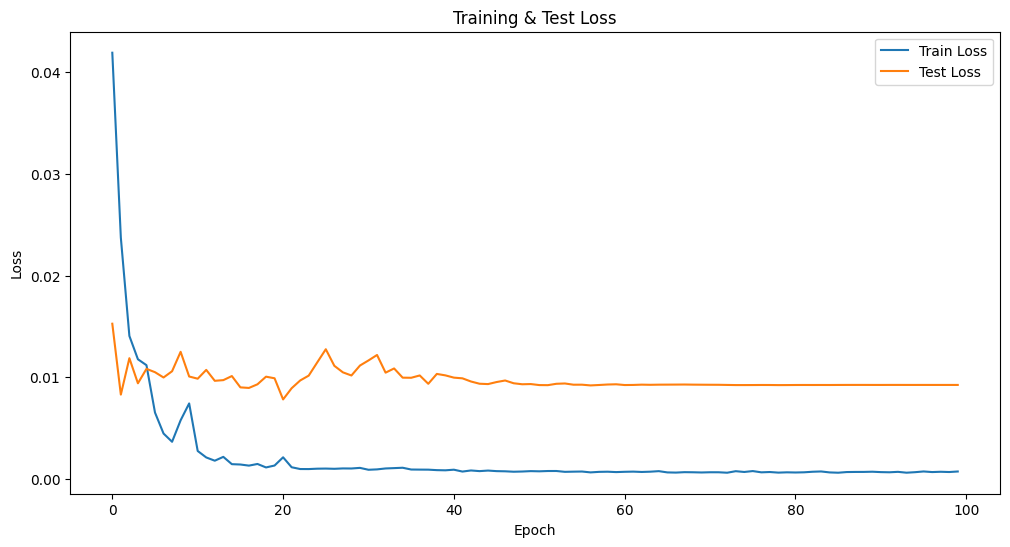

In [11]:
# Cell 10: Plot training and test losses
plt.figure(figsize=(12,6))
plt.plot(epoch_train_losses, label='Train Loss')
plt.plot(epoch_test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Test Loss')
plt.legend()
plt.show()

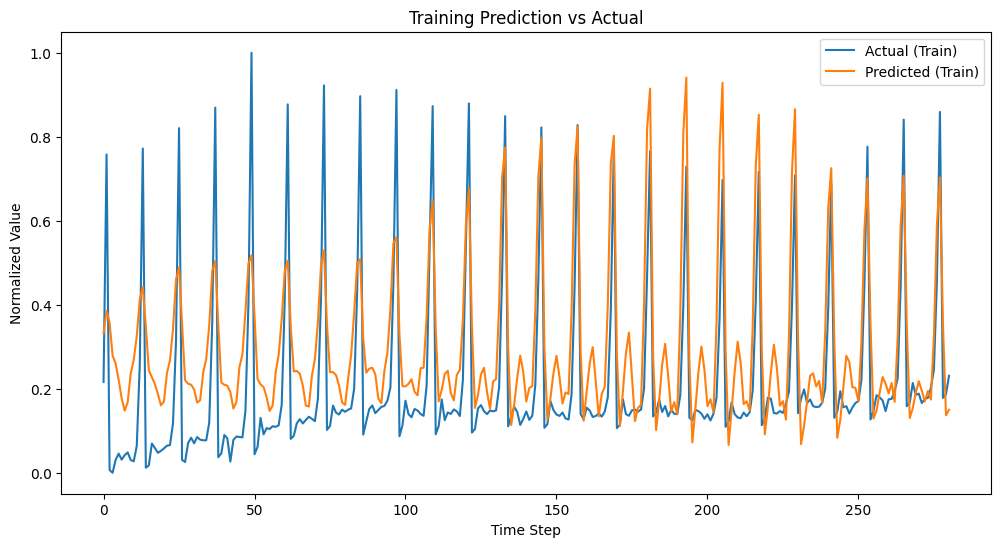

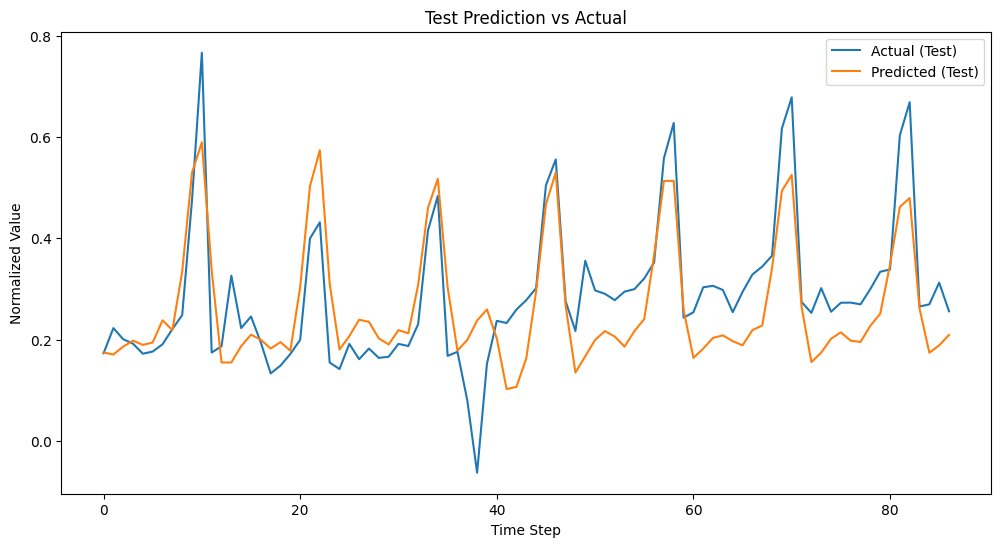

In [12]:
# Cell 11: Plot predictions vs actual
# Training
train_preds, train_actual = [], []
with torch.no_grad():
    for inputs, targets in train_loader:
        outputs = model(inputs)
        train_preds.append(outputs.item())
        train_actual.append(targets.item())

plt.figure(figsize=(12,6))
plt.plot(train_actual, label='Actual (Train)')
plt.plot(train_preds, label='Predicted (Train)')
plt.title('Training Prediction vs Actual')
plt.xlabel('Time Step')
plt.ylabel('Normalized Value')
plt.legend()
plt.show()

# Test
test_preds, test_actual = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = model(inputs)
        test_preds.append(outputs.item())
        test_actual.append(targets.item())

plt.figure(figsize=(12,6))
plt.plot(test_actual, label='Actual (Test)')
plt.plot(test_preds, label='Predicted (Test)')
plt.title('Test Prediction vs Actual')
plt.xlabel('Time Step')
plt.ylabel('Normalized Value')
plt.legend()
plt.show()